In [1]:
from sklearn.model_selection import TimeSeriesSplit
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path(__vsc_ipynb_file__).parent / "working_mo_df.csv"
raw_df = pd.read_csv(DATA_PATH)
raw_df

,Date,VIX_Close,Price To Book Value Per Share(Time Series Ratio),MO_Bid,MO_Ask,Company Market Cap,Net Debt,Net Cash Flow from Operating Activities,Short-Term Debt & Current Portion of Long-Term Debt,Debt - Long-Term - Total,...,Interpolated Government Spread,30D_A_IM_C,30D_A_IM_P,60D_A_IM_C,60D_A_IM_P,90D_A_IM_C,90D_A_IM_P,dd,basis_bps,edf_pct
0,2016-01-15,27.02,38.846853,57.19,57.20,1.121154e+11,10478000000,5843000000,4000000,12843000000,...,123.4458,23.48,23.48,21.50,21.50,21.17,21.17,15.603597,214.051184,0.04
1,2016-01-19,26.05,39.661822,58.40,58.41,1.144675e+11,10478000000,5843000000,4000000,12843000000,...,123.2495,22.11,22.11,21.62,21.62,21.29,21.29,15.339676,214.051184,0.04
2,2016-01-20,27.59,38.860436,57.21,57.22,1.121546e+11,10478000000,5843000000,4000000,12843000000,...,125.0509,25.29,25.29,23.34,23.34,22.70,22.70,14.997837,214.051184,0.04
3,2016-01-21,26.69,39.016638,57.45,57.46,1.126054e+11,10478000000,5843000000,4000000,12843000000,...,125.1433,23.61,23.61,22.43,22.43,22.09,22.09,14.999573,214.051184,0.04
4,2016-01-22,22.34,39.580325,58.27,58.28,1.142323e+11,10478000000,5843000000,4000000,12843000000,...,124.8558,21.05,21.05,19.22,19.22,20.04,20.04,15.094406,214.051184,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2026-01-12,15.12,-37.149486,58.52,58.53,9.801459e+10,21799000000,8753000000,1527000000,23399000000,...,89.6124,20.87,20.87,20.00,20.00,19.88,19.88,10.636751,214.051184,0.04
2496,2026-01-13,15.98,-38.171192,60.13,60.14,1.007102e+11,21799000000,8753000000,1527000000,23399000000,...,65.6160,18.53,18.53,19.41,19.41,19.32,19.32,10.401159,214.051184,0.04
2497,2026-01-14,16.75,-39.008864,61.48,61.49,1.029203e+11,21799000000,8753000000,1527000000,23399000000,...,66.2530,21.09,21.09,19.34,19.34,19.20,19.20,10.300490,214.051184,0.04
2498,2026-01-15,15.84,-39.078670,61.58,61.59,1.031045e+11,21799000000,8753000000,1527000000,23399000000,...,64.9396,20.94,20.94,19.31,19.31,19.37,19.37,10.307388,214.051184,0.04


In [3]:
df = raw_df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

# 30-day forward log-change in Z-spread (Predicting the next month)
# df['target_30d_log_delta_z'] = np.log(df['Z Spread'].shift(-30).clip(lower=5)) - np.log(df['Z Spread'].clip(lower=5))
# Neutralize against macro noise (VIX) to isolate Altria's idiosyncratic "Alpha"
mo_log_move = np.log(df['Z Spread'].shift(-30).clip(lower=5)) - np.log(df['Z Spread'].clip(lower=5))
vix_log_move = np.log(df['VIX_Close'].shift(-30).clip(lower=5)) - np.log(df['VIX_Close'].clip(lower=5))
df['target_residual'] = mo_log_move - vix_log_move

# DD Velocity: Is the firm moving toward or away from the default boundary?
df['dd_velocity_21d'] = df['dd'].diff(21)
df['dd_velocity_5d'] = df['dd'].diff(5)

df['term_structure_30_90'] = df['30D_A_IM_P'] - df['90D_A_IM_P']
df['term_structure_30_60'] = df['30D_A_IM_P'] - df['60D_A_IM_P']

# Velocity of Volatility
df['vol_30d_velocity'] = df['30D_A_IM_P'].diff(5) 

# Relative Volatility (How jumpy is it relative to the average?)
df['vol_zscore'] = (df['30D_A_IM_P'] - df['30D_A_IM_P'].rolling(252).mean()) / df['30D_A_IM_P'].rolling(252).std()

# Leverage Ratio: Standard credit anchor
df['leverage_ratio'] = df['Net Debt'] / df['Earnings before Interest Taxes Depreciation & Amortization'].replace(0, np.nan)
df['leverage_velocity_63d'] = df['leverage_ratio'].diff(63) # Quarterly change trend

df['asset_cushion'] = df['Total Assets'] / (df['Short-Term Debt & Current Portion of Long-Term Debt'] + df['Debt - Long-Term - Total']).replace(0, np.nan)

df['dts'] = df['Modified Duration'] * df['Z Spread']


# VIX Z-Score: Market panic relative to the last year
df['vix_rolling_mean'] = df['VIX_Close'].rolling(window=252).mean()
df['vix_rolling_std'] = df['VIX_Close'].rolling(window=252).std()
df['vix_zscore'] = (df['VIX_Close'] - df['vix_rolling_mean']) / df['vix_rolling_std'].replace(0, np.nan)

# Negative Equity Regime Flag; Important for Altria's 2026 data where P/B is negative
df['is_negative_equity'] = (df['Price To Book Value Per Share(Time Series Ratio)'] < 0).astype(int)

df['dd_x_neg_equity'] = df['dd'] * df['is_negative_equity']

# Drop the intermediate rolling columns used for Z-score
df = df.drop(columns=['vix_rolling_mean', 'vix_rolling_std'])

# List of finalized features for the model
feature_cols = [
    'dd', 'dd_velocity_21d', 'term_structure_30_90', 'term_structure_30_60', 'vol_30d_velocity', 'vol_zscore',
    'leverage_ratio', 'leverage_velocity_63d', 'asset_cushion',
    'dts', 'vix_zscore', 'is_negative_equity', 'Convexity', 'dd_x_neg_equity'
]

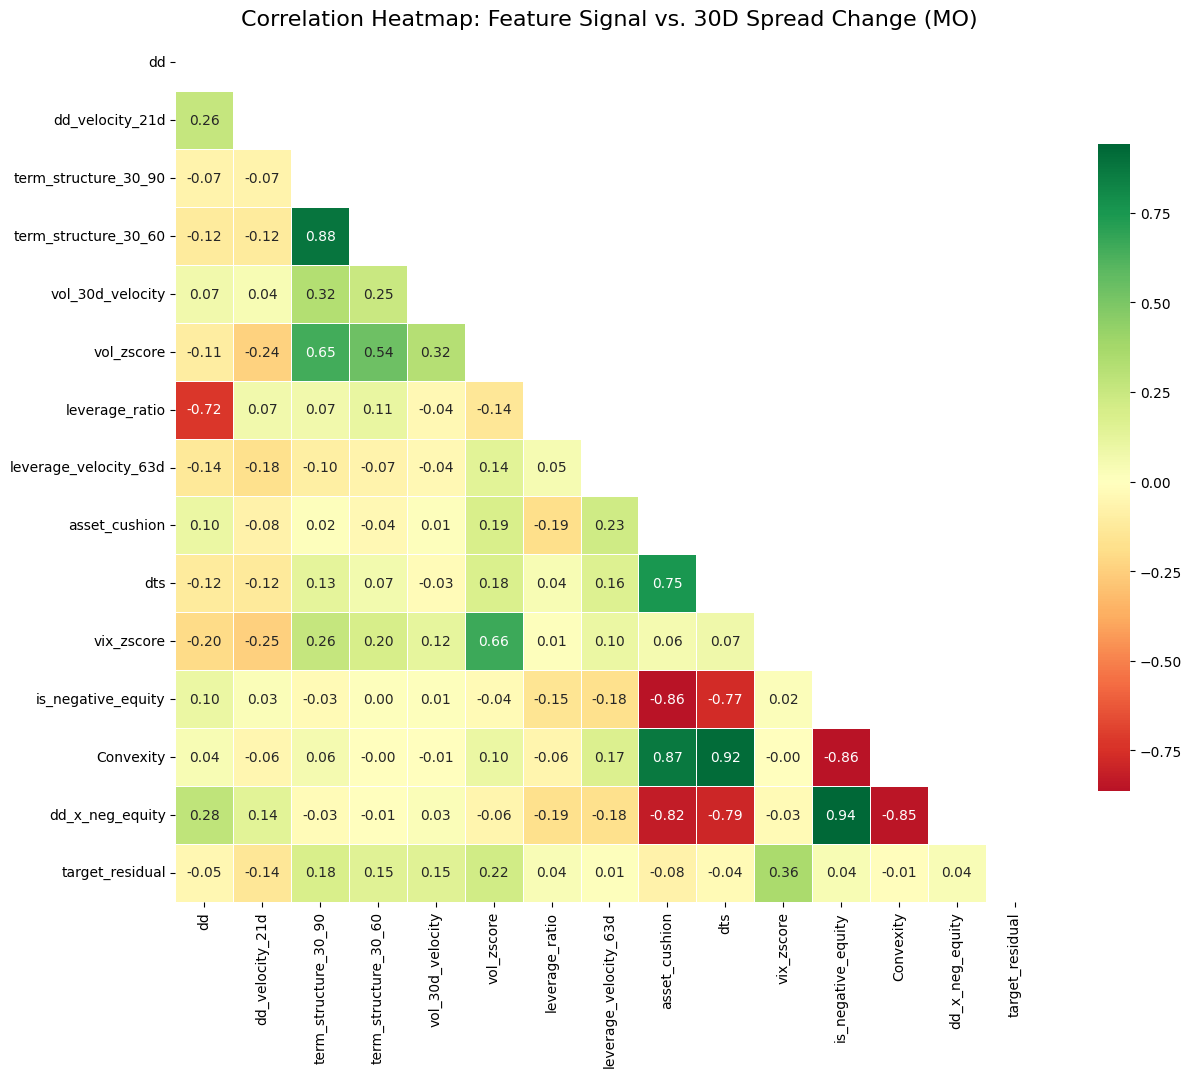

In [4]:
# 1. Define the subset of columns (Features + Target)
cols_to_check = feature_cols + ['target_residual'] #['target_30d_log_delta_z']


# 2. Compute the correlation matrix
# 'spearman' is preferred for credit/vol data which is rarely normally distributed
corr_matrix = df[cols_to_check].dropna().corr(method='spearman')

# 3. Create a mask for the upper triangle (optional, for cleaner look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Plotting
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='RdYlGn', # Red for negative, Green for positive
    center=0, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .7}
)

plt.title("Correlation Heatmap: Feature Signal vs. 30D Spread Change (MO)", fontsize=16)
plt.show()

Final pruning is essential to mitigate multicollinearity, preventing redundant features from cannibalizing each other’s importance and muddying the interpretability of SHAP values. 

By removing Convexity in favor of the 0.92-correlated DTS, the model is forced to attribute spread sensitivity to a single, industry-standard risk anchor. Prioritizing the 30/90 term structure and the continuous asset_cushion similarly streamlines the input space by favoring robust, granular signals over their binary or overlapping counterparts. 

This surgical cleanup ensures the XGBoost regressor identifies distinct credit regimes for Altria without being distracted by mathematical noise.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

df['dd_x_neg_equity'] = df['dd'] * df['is_negative_equity']

mo_log_move = np.log(df['Z Spread'].shift(-30).clip(lower=5)) - np.log(df['Z Spread'].clip(lower=5))
vix_log_move = np.log(df['VIX_Close'].shift(-30).clip(lower=5)) - np.log(df['VIX_Close'].clip(lower=5))

# Target is 1 if MO widens MORE than the VIX (Relative underperformance)
y_residual = (mo_log_move - vix_log_move)
y_class = (y_residual > 0).astype(int)

final_features = [
    'dd', 'leverage_velocity_63d', 'dts', 
    'dd_velocity_21d', 'term_structure_30_90', 'vix_zscore',
    'dd_x_neg_equity' 
]

X = df[final_features].dropna()
y_class = y_class.reindex(X.index)

# --- 1. SET UP TIME-DECAY PARAMETERS ---
# We want the most recent data to have significantly more influence
def get_sample_weights(idx_length, decay_rate=0.001):
    """Generates an exponential decay weight vector."""
    # Weights increase as we get closer to the present (end of the index)
    weights = np.exp(decay_rate * np.arange(idx_length))
    return weights / weights.mean() # Normalize to keep learning rate stable

tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_idx, test_idx in tscv.split(X):
    # Apply 30-day embargo
    train_idx_purged = train_idx[:-30] 
    
    X_train_f, X_test_f = X.iloc[train_idx_purged], X.iloc[test_idx]
    y_train_f, y_test_f = y_class.iloc[train_idx_purged], y_class.iloc[test_idx]
    
    # --- 2. CALCULATE WEIGHTS FOR THIS FOLD ---
    # Recent training rows get higher weights
    weights_train = get_sample_weights(len(X_train_f), decay_rate=0.002)
    
    fold_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    # --- 3. PASS WEIGHTS TO FIT ---
    fold_model.fit(X_train_f, y_train_f, sample_weight=weights_train)
    
    # Predict and evaluate
    preds = fold_model.predict(X_test_f)
    fold_hr = accuracy_score(y_test_f, preds)
    scores.append(fold_hr)

print(f"Validated Hit Rates (Weighted): {scores}")
print(f"Mean Hit Rate: {np.mean(scores):.2%}")

Validated Hit Rates (Weighted): [0.56951871657754, 0.5133689839572193, 0.6122994652406417, 0.48663101604278075, 0.37433155080213903]
Mean Hit Rate: 51.12%


/Users/mateo/Code/quant/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


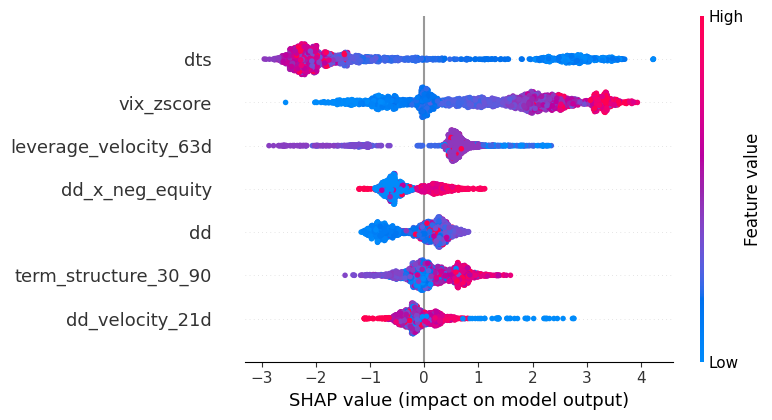

In [6]:
import shap
explainer = shap.TreeExplainer(fold_model)
# Look at the most recent test set where it's failing
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

In [7]:
# %%
# --- 1. FEATURE DELTA SCALING (Rolling Z-Scores) ---
# Define the features that need to be standardized relative to the local regime
z_score_targets = ['dd', 'leverage_ratio', 'asset_cushion', 'dts', 'term_structure_30_90']

for col in z_score_targets:
    # 252 days represents a standard trading year
    rolling_mean = df[col].rolling(window=252).mean()
    rolling_std = df[col].rolling(window=252).std()
    
    # Create the 'regime-aware' version of the feature
    df[f'{col}_z'] = (df[col] - rolling_mean) / rolling_std.replace(0, np.nan)

# Update the interaction term to use the Z-scored DD
df['dd_z_x_neg_equity'] = df['dd_z'] * df['is_negative_equity']

# --- 2. RE-DEFINE FEATURES AND TARGET ---
# We swap the raw levels for the Z-scored versions
final_features_z = [
    'dd_z', 'leverage_velocity_63d', 'dts_z', 
    'dd_velocity_21d', 'term_structure_30_90_z', 'vix_zscore',
    'dd_z_x_neg_equity' 
]

# Use the VIX-neutralized target we built earlier
X_z = df[final_features_z].dropna()
y_z = y_class.reindex(X_z.index)

# --- 3. TRAIN WITH AGGRESSIVE WEIGHTING ---
tscv = TimeSeriesSplit(n_splits=5)
scores_z = []

for train_idx, test_idx in tscv.split(X_z):
    train_idx_purged = train_idx[:-30] 
    
    X_train_f, X_test_f = X_z.iloc[train_idx_purged], X_z.iloc[test_idx]
    y_train_f, y_test_f = y_z.iloc[train_idx_purged], y_z.iloc[test_idx]
    
    # Using a steeper decay (0.005) to help the model forget the distant past
    weights_train = get_sample_weights(len(X_train_f), decay_rate=0.005)
    
    fold_model = XGBClassifier(
        n_estimators=150, # Slightly fewer trees to prevent overfitting the Z-scores
        max_depth=3,      # Shallow trees are more robust to regime shifts
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
    
    fold_model.fit(X_train_f, y_train_f, sample_weight=weights_train)
    
    preds = fold_model.predict(X_test_f)
    fold_hr = accuracy_score(y_test_f, preds)
    scores_z.append(fold_hr)

print(f"Validated Hit Rates (Z-Scaled + Weighted): {scores_z}")
print(f"Mean Hit Rate: {np.mean(scores_z):.2%}")

Validated Hit Rates (Z-Scaled + Weighted): [0.5187165775401069, 0.5106951871657754, 0.6336898395721925, 0.5427807486631016, 0.39037433155080214]
Mean Hit Rate: 51.93%


--- Fold 5 Comparison ---
XGBoost Fold 5 Hit Rate: 39.04%
LogReg Fold 5 Hit Rate:  50.80%


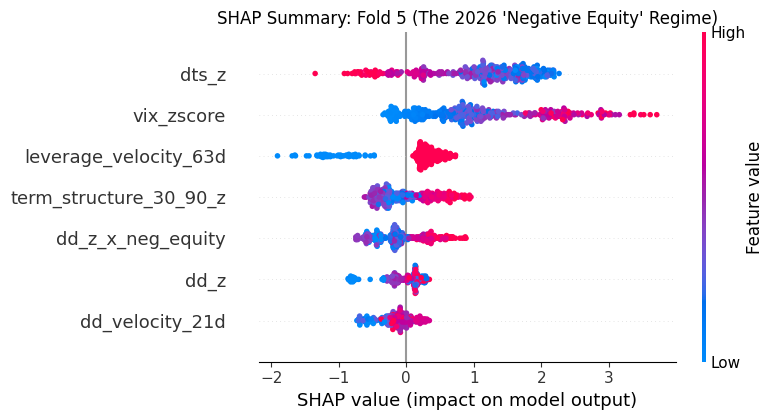


LogReg Coefficients (Positive = Widen, Negative = Tighten):
vix_zscore                0.855757
dd_z_x_neg_equity         0.496618
leverage_velocity_63d     0.495402
term_structure_30_90_z    0.079000
dd_z                      0.077257
dd_velocity_21d          -0.070657
dts_z                    -0.311813
dtype: float64


In [8]:
# %%
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# --- 1. RE-ISOLATE FOLD 5 (The 2026 Regime) ---
# We manually grab the last split from our TSCV
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, test_idx in tscv.split(X_z):
    pass # Loop to the end to get the last fold indices

train_idx_purged = train_idx[:-30]
X_train_f5, X_test_f5 = X_z.iloc[train_idx_purged], X_z.iloc[test_idx]
y_train_f5, y_test_f5 = y_z.iloc[train_idx_purged], y_z.iloc[test_idx]

# --- 2. LOGISTIC REGRESSION BASELINE ---
# Note: LogReg benefits from scaling even if data is already Z-scored
lr_model = LogisticRegression(C=0.1, random_state=42)
lr_model.fit(X_train_f5, y_train_f5)

lr_preds = lr_model.predict(X_test_f5)
lr_hit_rate = accuracy_score(y_test_f5, lr_preds)

print(f"--- Fold 5 Comparison ---")
print(f"XGBoost Fold 5 Hit Rate: 39.04%")
print(f"LogReg Fold 5 Hit Rate:  {lr_hit_rate:.2%}")

# --- 3. SHAP ANALYSIS FOR FOLD 5 ONLY ---
# We use the existing fold_model (which is the one trained on Fold 5)
explainer_f5 = shap.TreeExplainer(fold_model)
shap_values_f5 = explainer_f5.shap_values(X_test_f5)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: Fold 5 (The 2026 'Negative Equity' Regime)")
shap.summary_plot(shap_values_f5, X_test_f5)

# --- 4. DIRECTIONAL COEFFICIENTS ---
lr_coefs = pd.Series(lr_model.coef_[0], index=final_features_z)
print("\nLogReg Coefficients (Positive = Widen, Negative = Tighten):")
print(lr_coefs.sort_values(ascending=False))

In [9]:
# %%
# --- 1. DEFINE THE "NEW WORLD" REGIME ---
# We filter for data from 2022 onwards (Post-COVID / Negative Equity era)
regime_cutoff = '2022-01-01'
df_recent = df[df.index >= regime_cutoff].copy()

# --- 2. PREPARE THE DATA ---
X_recent = df_recent[final_features_z].dropna()
y_recent = (y_residual.reindex(X_recent.index) > 0).astype(int)

# Use a simpler TimeSeriesSplit for this smaller window
tscv_recent = TimeSeriesSplit(n_splits=3)
recent_scores = []

print(f"Testing 'Short-Memory' Model (Data since {regime_cutoff})...")

for train_idx, test_idx in tscv_recent.split(X_recent):
    # Reduced embargo for smaller dataset
    train_idx_purged = train_idx[:-10] 
    
    X_tr, X_te = X_recent.iloc[train_idx_purged], X_recent.iloc[test_idx]
    y_tr, y_te = y_recent.iloc[train_idx_purged], y_recent.iloc[test_idx]
    
    # Simpler model to avoid overfitting the smaller sample
    short_model = XGBClassifier(
        n_estimators=50, 
        max_depth=3, 
        learning_rate=0.05,
        random_state=42
    )
    
    short_model.fit(X_tr, y_tr)
    
    recent_preds = short_model.predict(X_te)
    recent_scores.append(accuracy_score(y_te, recent_preds))

print(f"Validated Hit Rates (Recent Only): {recent_scores}")
print(f"Mean Hit Rate (Short-Memory): {np.mean(recent_scores):.2%}")

# --- 3. THE "GOLDEN SIGNAL" CHECK ---
# If this is still low, we MUST pull the 25-Delta Skew we discussed earlier.

Testing 'Short-Memory' Model (Data since 2022-01-01)...
Validated Hit Rates (Recent Only): [0.396, 0.584, 0.5]
Mean Hit Rate (Short-Memory): 49.33%
